## Analysis

> All of the data is downloaded from Kenneth R. French data library 
> https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

### Description of data 

> The decile portfolios are downloaded straight from the data library and are contained in the files "10_Portfolios_Prior_12_2_Daily.csv" and "10_Portfolios_Prior_12_2.csv"
> The WML portfolio is calculated in this notbook with the available data from the decile portfolios.
> The Market portfolio and risk free returns are taken out of the Fama French 3 factor model for the same time horizon. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Monthly momentum deciles (value-weighted) ---
mom_monthly = pd.read_csv(
    'data/10_Portfolios_Prior_12_2.csv',
    skiprows=11,       # skip file header + section label line
    nrows=1192,        # only the VW monthly block (lines 12–1203)
    index_col=0,
    header=0
)
mom_monthly.index = mom_monthly.index.astype(str).str.strip()
mom_monthly = mom_monthly[mom_monthly.index.str.match(r'^\d{6}$')]
mom_monthly.index = pd.to_datetime(mom_monthly.index, format='%Y%m')
mom_monthly.columns = [f'D{i}' for i in range(1, 11)]
mom_monthly = mom_monthly.apply(pd.to_numeric, errors='coerce')
mom_monthly = mom_monthly.replace([-99.99, -999], np.nan) / 100

# WML = Winner (D10) - Loser (D1)
mom_monthly['WML'] = mom_monthly['D10'] - mom_monthly['D1']

# --- Fama-French factors (monthly) ---
ff_monthly = pd.read_csv(
    'data/F-F_Research_Data_Factors.csv',
    skiprows=4,
    index_col=0
)
ff_monthly.index = ff_monthly.index.astype(str).str.strip()
ff_monthly = ff_monthly[ff_monthly.index.str.match(r'^\d{6}$')]
ff_monthly.index = pd.to_datetime(ff_monthly.index, format='%Y%m')
ff_monthly = ff_monthly.apply(pd.to_numeric, errors='coerce') / 100

# Align
data = mom_monthly.join(ff_monthly, how='inner')

print(data.shape)
data.tail()


(1190, 15)


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,WML,Mkt-RF,SMB,HML,RF
2025-11-01,-0.0062,0.0307,0.0276,0.0725,0.0156,0.0240,0.0031,0.0019,-0.0140,-0.0363,-0.0301,-0.0013,0.0038,0.0376,0.0030
2025-12-01,0.0261,0.0223,0.0222,0.0047,0.0017,0.0105,-0.0073,-0.0049,-0.0039,-0.0026,-0.0287,-0.0036,-0.0106,0.0242,0.0034
2026-01-01,-0.0013,-0.0674,-0.0111,0.0521,0.0216,0.0067,-0.0462,0.0101,0.0234,0.0613,0.0626,0.0102,0.0220,0.0372,0.0030
2026-02-01,-0.0555,-0.0015,-0.0016,0.0108,-0.0320,0.0156,0.0130,-0.0310,0.0402,-0.0341,0.0214,-0.0117,0.0014,0.0283,0.0028
1927-01-01,-0.0047,0.0088,0.0410,0.0251,-0.0029,0.0242,0.0164,0.0098,-0.0039,0.0130,0.0177,-0.0005,-0.0032,0.0458,0.0025


In [11]:
# Replicate summary stats table (mean, std, skew, SR, min, max)
cols = ['D1', 'D10', 'WML', 'Mkt-RF']
labels = ['Loser (D1)', 'Winner (D10)', 'WML', 'Mkt-RF']

rows = []
for col, label in zip(cols, labels):
    s = data[col].dropna()
    rows.append({
        'Portfolio': label,
        'Mean (ann.)': s.mean() * 12,
        'Std (ann.)': s.std() * np.sqrt(12),
        'Skewness': s.skew(),
        'Sharpe Ratio': (s.mean() / s.std()) * np.sqrt(12),
        'Min': s.min(),
        'Max': s.max(),
    })

summary = pd.DataFrame(rows).set_index('Portfolio')
summary.style.format({
    'Mean (ann.)': '{:.2%}',
    'Std (ann.)': '{:.2%}',
    'Skewness': '{:.2f}',
    'Sharpe Ratio': '{:.2f}',
    'Min': '{:.2%}',
    'Max': '{:.2%}',
})


,Mean (ann.),Std (ann.),Skewness,Sharpe Ratio,Min,Max
Portfolio,,,,,,
Loser (D1),4.49%,33.86%,1.59,0.13,-42.26%,93.84%
Winner (D10),17.99%,22.23%,-0.49,0.81,-28.31%,28.68%
WML,13.50%,27.38%,-2.20,0.49,-78.04%,26.24%
Mkt-RF,8.25%,18.41%,0.15,0.45,-28.74%,38.81%


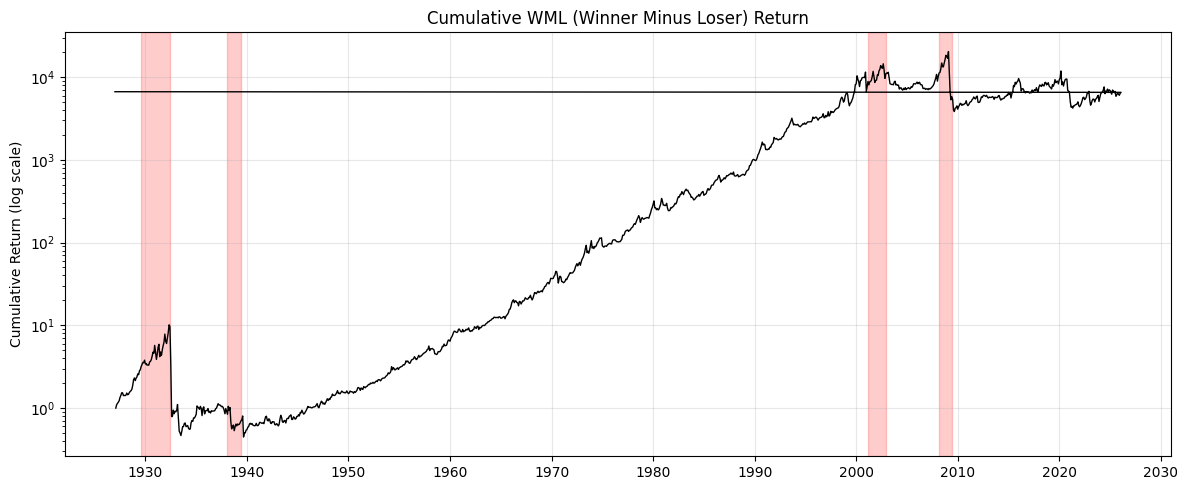

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

cum_wml = (1 + data['WML']).cumprod()
ax.plot(cum_wml.index, cum_wml, color='black', linewidth=1)
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log scale)')
ax.set_title('Cumulative WML (Winner Minus Loser) Return')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Shade NBER recession-like crash periods highlighted in D&M paper
crash_periods = [
    ('1929-08', '1932-06'),  # Great Depression
    ('1938-01', '1939-06'),
    ('2001-03', '2002-12'),  # Post dot-com
    ('2008-03', '2009-06'),  # GFC
]
for start, end in crash_periods:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               alpha=0.2, color='red', label='_nolegend_')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


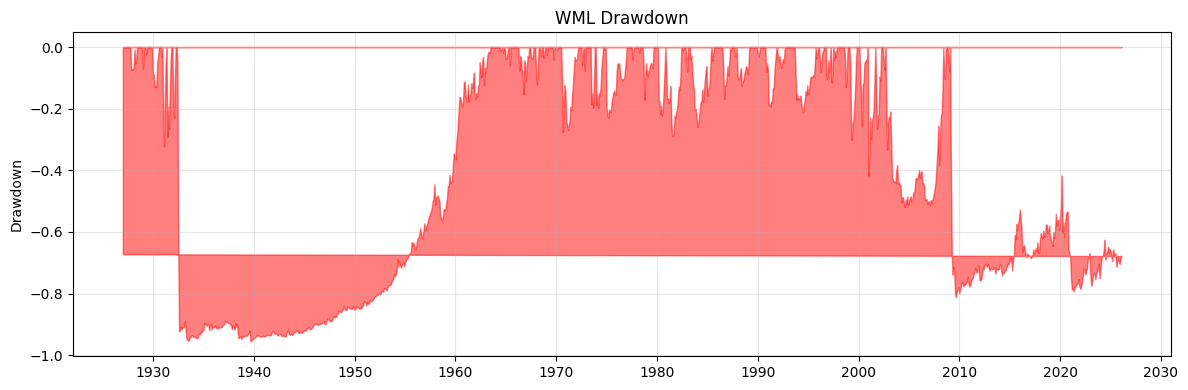

In [13]:
# Fig2: WML drawdown

cum = (1 + data['WML']).cumprod()
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.5)
ax.set_ylabel('Drawdown')
ax.set_title('WML Drawdown')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Fig3: conditional mean & volatility of WML (bear vs bull market)
# Define bear market state: past 2-year market return < 0 (lagged)
data['mkt_2yr'] = (1 + data['Mkt-RF']).rolling(24).apply(np.prod, raw=True) - 1
data['bear'] = (data['mkt_2yr'].shift(1) < 0).astype(int)

# Conditional stats
for state, label in [(0, 'Bull'), (1, 'Bear')]:
    subset = data[data['bear'] == state]['WML'].dropna()
    print(f"{label}: Mean={subset.mean()*12:.2%}, Std={subset.std()*np.sqrt(12):.2%}, "
          f"Skew={subset.skew():.2f}, N={len(subset)}")


Bull: Mean=17.12%, Std=19.76%, Skew=-0.18, N=915
Bear: Mean=1.46%, Std=43.97%, Skew=-2.07, N=275


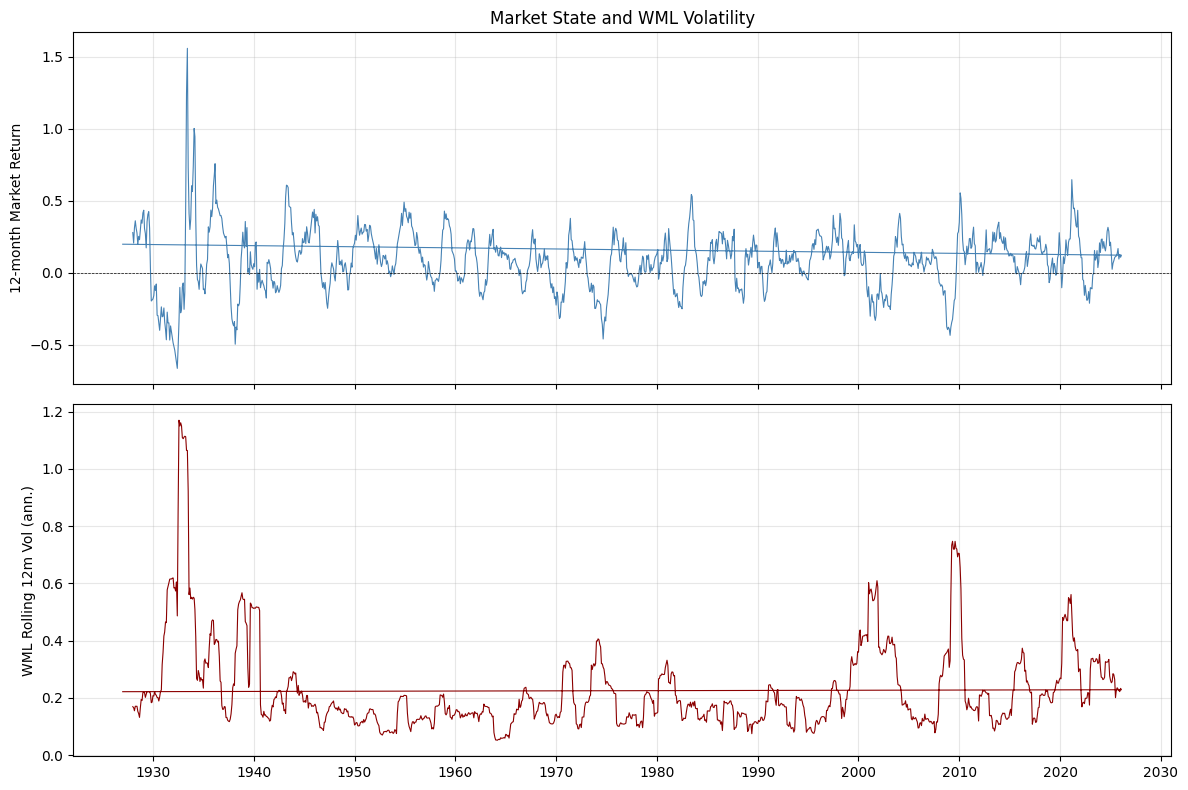

In [15]:
# Fig4 Rolling 12-month WML volatility vs lagged market return 

data['wml_vol_12'] = data['WML'].rolling(12).std() * np.sqrt(12)
data['mkt_12m'] = (1 + data['Mkt-RF']).rolling(12).apply(np.prod, raw=True) - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(data.index, data['mkt_12m'], color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('12-month Market Return')
axes[0].set_title('Market State and WML Volatility')

axes[1].plot(data.index, data['wml_vol_12'], color='darkred', linewidth=0.8)
axes[1].set_ylabel('WML Rolling 12m Vol (ann.)')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


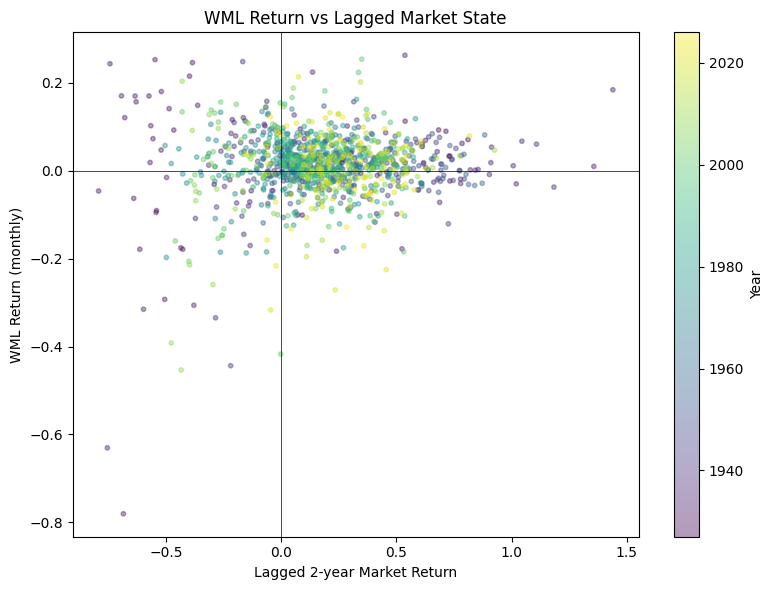

In [16]:
# Fig5: Scatter of lagged market return vs next-month WML return

plot_data = data[['Mkt-RF', 'WML', 'mkt_2yr']].dropna().copy()
plot_data['lagged_mkt_2yr'] = plot_data['mkt_2yr'].shift(1)
plot_data = plot_data.dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    plot_data['lagged_mkt_2yr'],
    plot_data['WML'],
    c=plot_data.index.year,
    cmap='viridis',
    alpha=0.4,
    s=10
)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lagged 2-year Market Return')
ax.set_ylabel('WML Return (monthly)')
ax.set_title('WML Return vs Lagged Market State')
plt.colorbar(sc, ax=ax, label='Year')
plt.tight_layout()
plt.show()


In [17]:
# Table2: WML performance by market state quintile 

plot_data['mkt_quintile'] = pd.qcut(plot_data['lagged_mkt_2yr'], 5,
                                     labels=['Q1\n(Bear)', 'Q2', 'Q3', 'Q4', 'Q5\n(Bull)'])

table2 = plot_data.groupby('mkt_quintile', observed=True)['WML'].agg(
    Mean=lambda x: x.mean() * 12,
    Std=lambda x: x.std() * np.sqrt(12),
    Skewness='skew',
    Sharpe=lambda x: (x.mean() / x.std()) * np.sqrt(12),
    N='count'
)
table2.style.format({
    'Mean': '{:.2%}',
    'Std': '{:.2%}',
    'Skewness': '{:.2f}',
    'Sharpe': '{:.2f}',
})


,Mean,Std,Skewness,Sharpe,N
mkt_quintile,,,,,
Q1 (Bear),-2.78%,45.57%,-1.97,-0.06,234
Q2,20.14%,22.32%,-1.54,0.90,233
Q3,16.09%,17.85%,0.08,0.90,233
Q4,17.12%,22.53%,-0.25,0.76,233
Q5 (Bull),14.25%,19.00%,-0.41,0.75,233
